# Практическая работа 5. Langfuse: трейсинг и мониторинг LLM

В работе рассматриваются возможности Langfuse для наблюдения за LLM-приложениями, управления промптами и оценки качества ответов.

### Задание 1. Базовое подключение и трейсинг

Подключим GigaChat к Langfuse Cloud и настроим запись промптов, ответов, длительности запросов, использованной модели и токенов. Проверим отображение трейсов, тегов и идентификаторов пользователя и сессии.

In [1]:
!pip install -q -U langfuse gigachat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.2/708.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.45.1 which is incompatible.
google-adk 2.7.1 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.45.1 which is incompatible.


In [2]:
import os
import time

from google.colab import userdata
from langfuse import get_client, propagate_attributes
from gigachat import GigaChat

for key in [
    "LANGFUSE_SECRET_KEY",
    "LANGFUSE_PUBLIC_KEY",
    "LANGFUSE_BASE_URL",
]:
    os.environ[key] = userdata.get(key)

GIGACHAT_CREDENTIALS = userdata.get("GIGACHAT_CREDENTIALS")

In [3]:
langfuse = get_client()

gigachat_client = GigaChat(
    credentials=GIGACHAT_CREDENTIALS,
    scope="GIGACHAT_API_PERS",
    base_url="https://api.giga.chat/v1",
    verify_ssl_certs=False,
)

MODEL = "GigaChat-2"

print("Langfuse configured")
print("GigaChat configured")

Langfuse configured
GigaChat configured


Напишем функцию для вызова LLM:

In [4]:
def call_llm(prompt, user_id="student_1", session_id="practice_5_session"):
    with langfuse.start_as_current_observation(
        as_type="span",
        name="gigachat-request",
        input=prompt,
    ) as trace:

        with propagate_attributes(
            user_id=user_id,
            session_id=session_id,
            tags=["test", "baseline", "experiment1"],
        ):

            with langfuse.start_as_current_observation(
                as_type="generation",
                name="gigachat-generation",
                model=MODEL,
                input=prompt,
            ) as generation:

                start = time.perf_counter()

                response = gigachat_client.chat({
                    "model": MODEL,
                    "messages": [
                        {"role": "user", "content": prompt}
                    ],
                    "temperature": 0,
                    "max_tokens": 200,
                })

                elapsed = time.perf_counter() - start

                answer = response.choices[0].message.content
                usage = response.usage

                generation.update(
                    output=answer,
                    usage_details={
                        "input_tokens": usage.prompt_tokens,
                        "output_tokens": usage.completion_tokens,
                        "total_tokens": usage.total_tokens,
                    },
                    metadata={
                        "generation_time_sec": round(elapsed, 3),
                    },
                )

            trace.update(output=answer)

    langfuse.flush()

    return {
        "answer": answer,
        "time_sec": elapsed,
        "prompt_tokens": usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
    }

Тестовый запрос, чтобы убедиться, что всё работает:

In [8]:
test_prompt = "Кратко объясни, что такое машинное обучение."

result = call_llm(test_prompt)

print("Answer:", result["answer"])
print("Time:", round(result["time_sec"], 2), "sec")
print("Prompt tokens:", result["prompt_tokens"])
print("Completion tokens:", result["completion_tokens"])
print("Total tokens:", result["total_tokens"])

Answer: Машинное обучение — это область искусственного интеллекта, позволяющая компьютерам автоматически улучшать свои результаты благодаря опыту без явного программирования всех возможных решений. Компьютер учится на примерах данных, выявляет закономерности и строит модели, способные эффективно решать задачи классификации, регрессии, распознавания образов и другие.
Time: 2.05 sec
Prompt tokens: 25
Completion tokens: 64
Total tokens: 89


### Тестирование трейсинга

Выполняем 10 запросов к GigaChat через Langfuse. Для каждого запроса сохраняются промпт, ответ, модель, длительность, количество токенов, теги, `user_id` и `session_id`.

In [9]:
test_prompts = [
    "Что такое RAG?",
    "Объясни разницу между CPU и GPU.",
    "Что такое эмбеддинги?",
    "Зачем в машинном обучении нужна валидационная выборка?",
    "Объясни, что такое API.",
    "Что такое векторная база данных?",
    "Чем классификация отличается от регрессии?",
    "Что такое переобучение модели?",
    "Для чего используется Cross-Encoder?",
]

trace_results = []

# Добавляем результат первого успешного запроса
trace_results.append({
    "prompt": test_prompt,
    **result,
})

for i, prompt in enumerate(test_prompts, start=2):
    response = call_llm(prompt)

    trace_results.append({
        "prompt": prompt,
        **response,
    })

    print(
        f"{i}/10 | "
        f"{response['time_sec']:.2f} sec | "
        f"{response['total_tokens']} tokens"
    )

2/10 | 1.78 sec | 224 tokens
3/10 | 1.33 sec | 228 tokens
4/10 | 1.39 sec | 221 tokens
5/10 | 1.33 sec | 232 tokens
6/10 | 1.36 sec | 227 tokens
7/10 | 1.50 sec | 221 tokens
8/10 | 1.41 sec | 226 tokens
9/10 | 1.54 sec | 226 tokens
10/10 | 1.32 sec | 226 tokens


In [10]:
import pandas as pd

trace_df = pd.DataFrame(trace_results)

trace_df[
    [
        "prompt",
        "time_sec",
        "prompt_tokens",
        "completion_tokens",
        "total_tokens",
    ]
]

,prompt,time_sec,prompt_tokens,completion_tokens,total_tokens
0,"Кратко объясни, что такое машинное обучение.",2.050214,25,64,89
1,Что такое RAG?,1.777987,24,200,224
2,Объясни разницу между CPU и GPU.,1.333621,28,200,228
3,Что такое эмбеддинги?,1.390613,21,200,221
4,Зачем в машинном обучении нужна валидационная ...,1.327998,32,200,232
5,"Объясни, что такое API.",1.363145,27,200,227
6,Что такое векторная база данных?,1.503968,21,200,221
7,Чем классификация отличается от регрессии?,1.409995,26,200,226
8,Что такое переобучение модели?,1.542823,26,200,226
9,Для чего используется Cross-Encoder?,1.324931,26,200,226


In [11]:
print("Всего запросов:", len(trace_df))
print("Среднее время:", round(trace_df["time_sec"].mean(), 2), "sec")
print("Минимальное время:", round(trace_df["time_sec"].min(), 2), "sec")
print("Максимальное время:", round(trace_df["time_sec"].max(), 2), "sec")
print("Всего токенов:", trace_df["total_tokens"].sum())

Всего запросов: 10
Среднее время: 1.5 sec
Минимальное время: 1.32 sec
Максимальное время: 2.05 sec
Всего токенов: 2120


В интерфейсе Langfuse видим следующее:

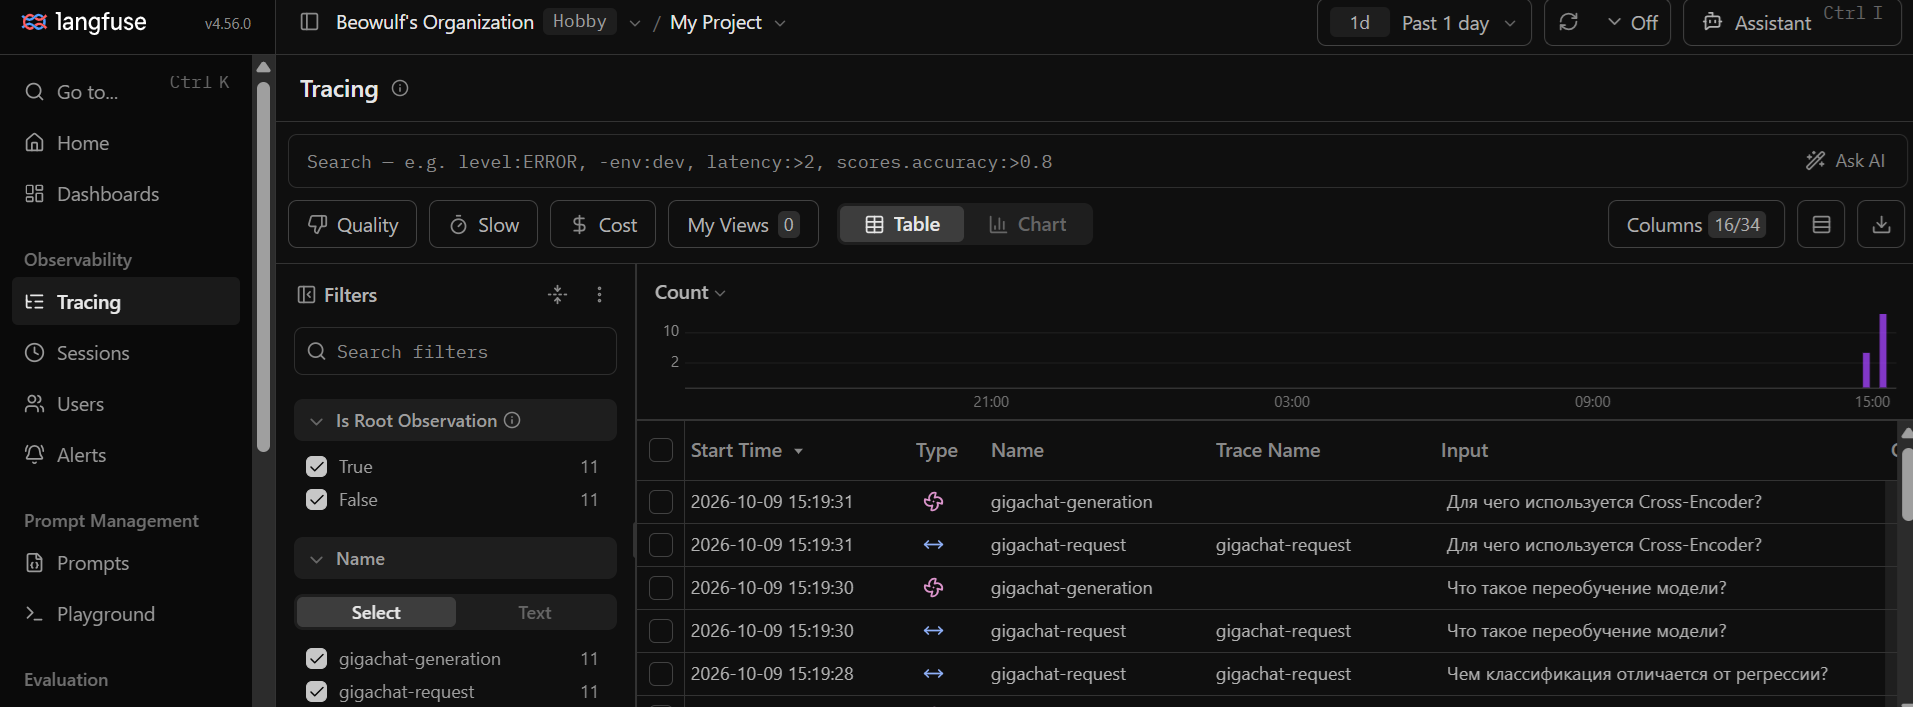

### Вывод

В ходе эксперимента Langfuse был успешно подключён к GigaChat через Python SDK. Выполнено 10 тестовых запросов, для которых настроено логирование промптов, ответов, модели, длительности генерации и количества токенов.

Среднее время ответа составило **1,50 с**, минимальное — **1,32 с**, максимальное — **2,05 с**. Суммарно использовано **2120 токенов**.

В интерфейсе Langfuse отображается структура вызовов с родительским `span` и вложенным `generation`. Также настроена передача тегов, `user_id` и `session_id`.

Таким образом, Langfuse позволяет централизованно отслеживать работу LLM-приложения, анализировать задержки и расход токенов, просматривать входные и выходные данные и находить потенциальные проблемы при выполнении запросов.

## Задание 2. Версионирование промптов

Создадим три версии промпта в Langfuse Prompt Management: базовую, улучшенную и вариант с системной инструкцией.

Все версии будут протестированы на одинаковых пяти вопросах. Сравним качество, длину ответов, время генерации и количество токенов.

In [12]:
PROMPT_NAME = "practice-5-technical-explanations"

prompt_v1 = [
    {
        "role": "user",
        "content": "Объясни простыми словами: {{question}}"
    }
]

prompt_v2 = [
    {
        "role": "user",
        "content": (
            "Объясни следующий вопрос простым и понятным языком: {{question}}\n"
            "Дай краткое определение, объясни практическое применение "
            "и приведи один пример. Избегай лишних подробностей."
        )
    }
]

prompt_v3 = [
    {
        "role": "system",
        "content": (
            "Ты преподаватель основ машинного обучения и программирования. "
            "Отвечай точно, понятно и по-русски. "
            "Структурируй ответ в три пункта: "
            "1. Определение; 2. Применение; 3. Пример. "
            "Не добавляй информацию, в которой не уверен."
        )
    },
    {
        "role": "user",
        "content": "{{question}}"
    }
]

Теперь сохраним их в Langfuse. Порядок важен: сервис автоматически присваивает каждой новой версии следующий номер.

In [13]:
for name, prompt in [
    ("v1", prompt_v1),
    ("v2", prompt_v2),
    ("v3", prompt_v3),
]:
    created = langfuse.create_prompt(
        name=PROMPT_NAME,
        type="chat",
        prompt=prompt,
        labels=[name],
    )

    print(f"{name}: Langfuse version {created.version}")

v1: Langfuse version 1
v2: Langfuse version 2
v3: Langfuse version 3


Проверяем получение версий через API:

In [14]:
prompts = {}

for label in ["v1", "v2", "v3"]:
    prompt = langfuse.get_prompt(
        PROMPT_NAME,
        label=label,
    )

    prompts[label] = prompt

    print(f"\n{label}: version={prompt.version}")
    print(prompt.compile(question="Что такое RAG?"))


v1: version=1
[{'role': 'user', 'content': 'Объясни простыми словами: Что такое RAG?'}]

v2: version=2
[{'role': 'user', 'content': 'Объясни следующий вопрос простым и понятным языком: Что такое RAG?\nДай краткое определение, объясни практическое применение и приведи один пример. Избегай лишних подробностей.'}]

v3: version=3
[{'role': 'system', 'content': 'Ты преподаватель основ машинного обучения и программирования. Отвечай точно, понятно и по-русски. Структурируй ответ в три пункта: 1. Определение; 2. Применение; 3. Пример. Не добавляй информацию, в которой не уверен.'}, {'role': 'user', 'content': 'Что такое RAG?'}]


In [15]:
test_questions = [
    "Что такое RAG?",
    "Что такое эмбеддинги?",
    "Для чего используется Cross-Encoder?",
    "Чем классификация отличается от регрессии?",
    "Что такое переобучение модели?",
]

### Тестирование версий промпта

Три версии промпта тестируются на пяти одинаковых вопросах с использованием `GigaChat-2`.

Для каждого ответа фиксируются длительность генерации, количество токенов, длина текста и версия промпта. Все вызовы записываются в Langfuse.

In [16]:
def call_llm_with_prompt_version(question, version):
    prompt = prompts[version]
    messages = prompt.compile(question=question)

    with langfuse.start_as_current_observation(
        as_type="span",
        name="prompt-version-test",
        input=question,
    ) as trace:

        with propagate_attributes(
            user_id="student_1",
            session_id="practice_5_prompt_versions",
            tags=["experiment2", version],
        ):

            with langfuse.start_as_current_observation(
                as_type="generation",
                name="gigachat-generation",
                model=MODEL,
                input=messages,
                prompt=prompt,
            ) as generation:

                start = time.perf_counter()

                response = gigachat_client.chat({
                    "model": MODEL,
                    "messages": messages,
                    "temperature": 0,
                    "max_tokens": 300,
                })

                elapsed = time.perf_counter() - start
                answer = response.choices[0].message.content
                usage = response.usage

                generation.update(
                    output=answer,
                    usage_details={
                        "input_tokens": usage.prompt_tokens,
                        "output_tokens": usage.completion_tokens,
                        "total_tokens": usage.total_tokens,
                    },
                    metadata={
                        "prompt_version": prompt.version,
                        "generation_time_sec": round(elapsed, 3),
                    },
                )

            trace.update(output=answer)

    return {
        "version": version,
        "question": question,
        "answer": answer,
        "answer_chars": len(answer),
        "time_sec": elapsed,
        "prompt_tokens": usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
    }

In [17]:
experiment_results = []

for version in ["v1", "v2", "v3"]:
    print("\n" + "=" * 70)
    print("VERSION:", version)

    for question in test_questions:
        result = call_llm_with_prompt_version(question, version)
        experiment_results.append(result)

        print(
            f"{question[:35]:35} | "
            f"{result['time_sec']:.2f} sec | "
            f"{result['total_tokens']} tokens | "
            f"{result['answer_chars']} chars"
        )

langfuse.flush()


VERSION: v1
Что такое RAG?                      | 2.56 sec | 209 tokens | 877 chars
Что такое эмбеддинги?               | 1.75 sec | 295 tokens | 1174 chars
Для чего используется Cross-Encoder | 1.16 sec | 188 tokens | 836 chars
Чем классификация отличается от рег | 1.07 sec | 185 tokens | 762 chars
Что такое переобучение модели?      | 1.27 sec | 210 tokens | 865 chars

VERSION: v2
Что такое RAG?                      | 1.24 sec | 232 tokens | 907 chars
Что такое эмбеддинги?               | 1.43 sec | 272 tokens | 736 chars
Для чего используется Cross-Encoder | 0.94 sec | 188 tokens | 694 chars
Чем классификация отличается от рег | 1.01 sec | 198 tokens | 668 chars
Что такое переобучение модели?      | 1.32 sec | 253 tokens | 988 chars

VERSION: v3
Что такое RAG?                      | 1.50 sec | 313 tokens | 1211 chars
Что такое эмбеддинги?               | 1.65 sec | 344 tokens | 1171 chars
Для чего используется Cross-Encoder | 1.44 sec | 298 tokens | 1057 chars
Чем классификация отл

In [18]:
experiment_df = pd.DataFrame(experiment_results)

experiment_df[
    [
        "version",
        "question",
        "time_sec",
        "answer_chars",
        "prompt_tokens",
        "completion_tokens",
        "total_tokens",
    ]
]

,version,question,time_sec,answer_chars,prompt_tokens,completion_tokens,total_tokens
0,v1,Что такое RAG?,2.561339,877,30,179,209
1,v1,Что такое эмбеддинги?,1.753161,1174,27,268,295
2,v1,Для чего используется Cross-Encoder?,1.158953,836,32,156,188
3,v1,Чем классификация отличается от регрессии?,1.068074,762,32,153,185
4,v1,Что такое переобучение модели?,1.265663,865,27,183,210
5,v2,Что такое RAG?,1.236539,907,54,178,232
6,v2,Что такое эмбеддинги?,1.425567,736,61,211,272
7,v2,Для чего используется Cross-Encoder?,0.944675,694,56,132,188
8,v2,Чем классификация отличается от регрессии?,1.011005,668,56,142,198
9,v2,Что такое переобучение модели?,1.317142,988,56,197,253


In [19]:
version_summary_df = (
    experiment_df
    .groupby("version")[
        ["time_sec", "answer_chars", "total_tokens"]
    ]
    .agg(["mean", "std"])
    .round(2)
)

version_summary_df

time_sec       answer_chars         total_tokens       
            mean   std         mean     std         mean    std
version                                                        
v1          1.56  0.62        902.8  158.06        217.4  44.89
v2          1.19  0.20        798.6  141.01        228.6  35.62
v3          1.50  0.14       1100.6  122.69        308.0  30.67

In [20]:
for version in ["v1", "v2", "v3"]:
    print("\n" + "=" * 80, version)

    for row in experiment_results:
        if row["version"] == version:
            print("\nQUESTION:", row["question"])
            print("ANSWER:", row["answer"])


================================================================================ v1

QUESTION: Что такое RAG?
ANSWER: RAG расшифровывается как **Reasoning About Generality** («Обоснование обобщений»). Это подход, помогающий людям и искусственному интеллекту рассуждать правильно и избегать ошибок, когда приходится делать выводы или обобщения на основе неполной или ограниченной информации.

Простыми словами:

Представь ситуацию: ты видишь одну белую кошку и делаешь вывод, что «все кошки белые». Но это неверно, ведь ты видел всего лишь одну кошку. RAG учит нас проверять наши предположения и не спешить с выводами, пока мы не убедимся, что собрали достаточно примеров и фактов.

Применяется RAG обычно тогда, когда нужно убедиться, что выводы сделаны корректно и обоснованно, чтобы избежать поспешных или ошибочных решений. Например, искусственный интеллект с помощью RAG учится анализировать, насколько справедливо распространять найденную информацию на большие группы объектов или ситуаций.

QU

Пример в Langfuse для одного из промптов версии 3:

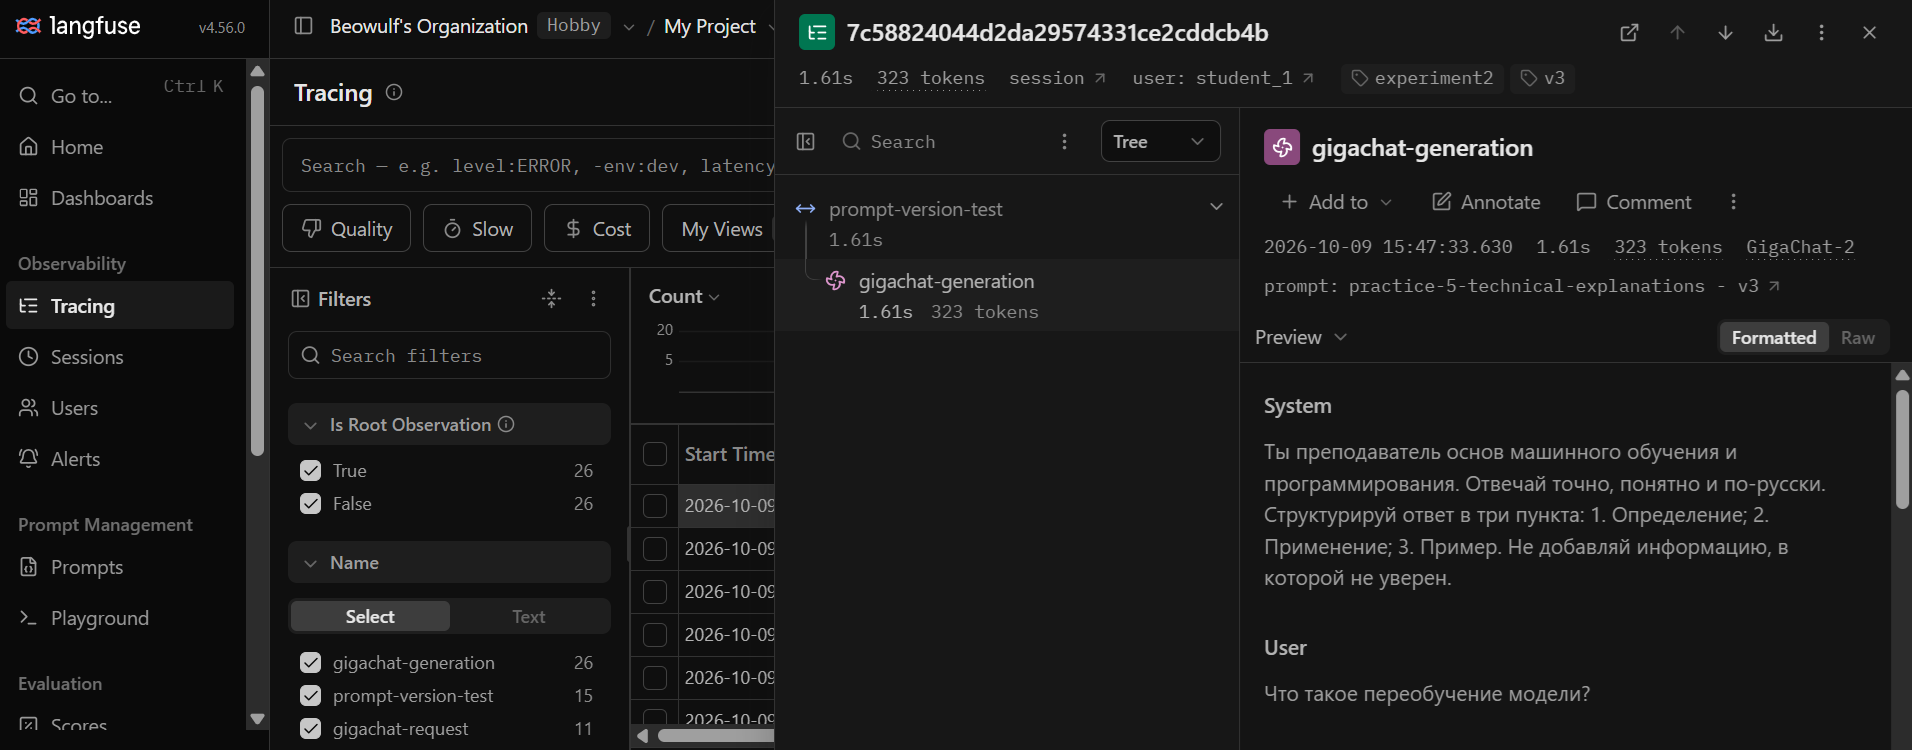

### Вывод

В Langfuse созданы три версии промпта, которые были загружены через API и протестированы на пяти одинаковых вопросах с использованием `GigaChat-2`.

**v1** давала содержательные, но не всегда структурированные ответы. **v2** обеспечила наименьшее среднее время генерации (1,19 с) и наиболее компактные ответы. **v3**, использующая отдельную системную инструкцию, показала наиболее последовательную структуру ответов и наименьший разброс времени генерации (std = 0,14 с), но потребовала больше токенов.

В ходе проверки обнаружены фактические ошибки: v1 и v2 неправильно расшифровали аббревиатуру RAG. Версия v3 ответила на этот вопрос корректно, хотя также допустила отдельную техническую неточность при объяснении Cross-Encoder.

**Таким образом, наиболее удачной для данного эксперимента оказалась v3:** системная инструкция улучшила соблюдение структуры и общую точность ответов. При этом более подробные инструкции увеличили длину ответа и расход токенов.

Эксперимент показывает, что версионирование промптов в Langfuse позволяет сравнивать изменения качества, скорости и стоимости генерации, а также обнаруживать ошибки, которые не выявляются только по количественным метрикам.

## Задание 3. A/B-тестирование промптов

Сравниваются две версии промпта из предыдущего задания: A (`v2`) и B (`v3`).

Для 30 запросов реализуется случайное распределение 50/50. Фиксируются версия промпта, время ответа, количество токенов и пользовательская оценка качества.

Результаты сохраняются в Langfuse и используются для сравнения средней задержки, расхода токенов и качества ответов.

In [21]:
import random
import pandas as pd
import time

ab_prompts = {
    "A": langfuse.get_prompt(PROMPT_NAME, version=2),
    "B": langfuse.get_prompt(PROMPT_NAME, version=3),
}

for variant, prompt in ab_prompts.items():
    print(f"{variant}: version={prompt.version}")

A: version=2
B: version=3


Сделаем ровно 15 запросов для каждого варианта. Порядок перемешаем случайным образом:

In [22]:
random.seed(42)

variants = ["A"] * 15 + ["B"] * 15
random.shuffle(variants)

# Каждый вопрос встречается 6 раз
questions = test_questions * 6
random.shuffle(questions)

print("Всего запросов:", len(variants))
print("A:", variants.count("A"))
print("B:", variants.count("B"))

Всего запросов: 30
A: 15
B: 15


In [24]:
def call_ab_model(question, variant):
    prompt = ab_prompts[variant]
    messages = prompt.compile(question=question)

    with langfuse.start_as_current_observation(
        as_type="span",
        name="ab-prompt-test",
        input=question,
    ) as trace:

        with propagate_attributes(
            user_id="student_1",
            session_id="practice_5_ab_test",
            tags=["experiment3", f"variant_{variant}"],
        ):

            with langfuse.start_as_current_observation(
                as_type="generation",
                name="gigachat-generation",
                model=MODEL,
                input=messages,
                prompt=prompt,
            ) as generation:

                start = time.perf_counter()

                response = gigachat_client.chat({
                    "model": MODEL,
                    "messages": messages,
                    "temperature": 0,
                    "max_tokens": 300,
                })

                elapsed = time.perf_counter() - start
                answer = response.choices[0].message.content
                usage = response.usage

                generation.update(
                    output=answer,
                    usage_details={
                        "input_tokens": usage.prompt_tokens,
                        "output_tokens": usage.completion_tokens,
                        "total_tokens": usage.total_tokens,
                    },
                    metadata={
                        "variant": variant,
                        "prompt_version": prompt.version,
                    },
                )

            trace.update(output=answer)
            trace_id = trace.trace_id

    return {
        "variant": variant,
        "prompt_version": prompt.version,
        "question": question,
        "answer": answer,
        "time_sec": elapsed,
        "total_tokens": usage.total_tokens,
        "trace_id": trace_id,
    }

Выполняем 30 запросов:

In [25]:
ab_results = []

for i, (variant, question) in enumerate(zip(variants, questions), start=1):
    result = call_ab_model(question, variant)
    ab_results.append(result)

    print(
        f"{i:02d}/30 | "
        f"{variant} | "
        f"{result['time_sec']:.2f} sec | "
        f"{result['total_tokens']} tokens"
    )

langfuse.flush()

01/30 | B | 2.54 sec | 268 tokens
02/30 | A | 1.88 sec | 330 tokens
03/30 | A | 1.45 sec | 242 tokens
04/30 | B | 1.41 sec | 294 tokens
05/30 | B | 2.14 sec | 381 tokens
06/30 | A | 1.31 sec | 235 tokens
07/30 | A | 1.20 sec | 203 tokens
08/30 | A | 1.07 sec | 186 tokens
09/30 | A | 1.99 sec | 338 tokens
10/30 | B | 1.40 sec | 281 tokens
11/30 | A | 1.20 sec | 240 tokens
12/30 | B | 2.02 sec | 357 tokens
13/30 | B | 1.42 sec | 298 tokens
14/30 | B | 1.76 sec | 352 tokens
15/30 | B | 1.64 sec | 327 tokens
16/30 | B | 1.52 sec | 296 tokens
17/30 | A | 1.52 sec | 273 tokens
18/30 | A | 1.76 sec | 325 tokens
19/30 | B | 1.92 sec | 384 tokens
20/30 | A | 1.07 sec | 205 tokens
21/30 | B | 1.20 sec | 260 tokens
22/30 | B | 1.46 sec | 306 tokens
23/30 | A | 1.15 sec | 198 tokens
24/30 | B | 1.33 sec | 285 tokens
25/30 | A | 1.46 sec | 248 tokens
26/30 | A | 1.19 sec | 223 tokens
27/30 | B | 1.49 sec | 313 tokens
28/30 | A | 1.11 sec | 204 tokens
29/30 | A | 1.33 sec | 248 tokens
30/30 | B | 1.

In [26]:
ab_df = pd.DataFrame(ab_results)

ab_df[
    [
        "variant",
        "prompt_version",
        "question",
        "time_sec",
        "total_tokens",
    ]
]

,variant,prompt_version,question,time_sec,total_tokens
0,B,3,Что такое переобучение модели?,2.538520,268
1,A,2,Чем классификация отличается от регрессии?,1.877847,330
2,A,2,Что такое RAG?,1.452810,242
3,B,3,Что такое эмбеддинги?,1.409294,294
4,B,3,Что такое эмбеддинги?,2.142279,381
5,A,2,Что такое RAG?,1.313706,235
6,A,2,Для чего используется Cross-Encoder?,1.203921,203
7,A,2,Для чего используется Cross-Encoder?,1.067145,186
8,A,2,Что такое эмбеддинги?,1.991492,338
9,B,3,Что такое переобучение модели?,1.401313,281


In [27]:
ab_summary = (
    ab_df.groupby("variant")
    .agg(
        requests=("variant", "count"),
        avg_time_sec=("time_sec", "mean"),
        avg_tokens=("total_tokens", "mean"),
    )
    .round(2)
)

ab_summary

,requests,avg_time_sec,avg_tokens
variant,,,
A,15,1.38,246.53
B,15,1.63,310.80


Для оценки фактической точности можем придумать какую-нибудь шкалу. Например:

| Оценка | Критерий |
|--------|----------|
| 5 | Правильный, понятный и достаточно полный ответ |
| 4 | В целом правильный ответ с небольшой неточностью |
| 3 | Полезный ответ, но есть заметная техническая ошибка |
| 2 | Существенная фактическая ошибка |
| 1 | Неверный или практически бесполезный ответ |

In [29]:
# оценку текстовых ответов и выставление баллов поручил SOTA LLM

quality_scores = [
    5, 5, 3, 5, 4,
    5, 5, 5, 4, 5,
    5, 4, 3, 5, 5,
    3, 5, 4, 5, 5,
    5, 5, 5, 3, 2,
    5, 5, 2, 4, 5,
]

assert len(quality_scores) == len(ab_results) == 30

ab_df["quality_score"] = quality_scores

ab_df[
    ["variant", "question", "time_sec", "total_tokens", "quality_score"]
]

,variant,question,time_sec,total_tokens,quality_score
0,B,Что такое переобучение модели?,2.538520,268,5
1,A,Чем классификация отличается от регрессии?,1.877847,330,5
2,A,Что такое RAG?,1.452810,242,3
3,B,Что такое эмбеддинги?,1.409294,294,5
4,B,Что такое эмбеддинги?,2.142279,381,4
5,A,Что такое RAG?,1.313706,235,5
6,A,Для чего используется Cross-Encoder?,1.203921,203,5
7,A,Для чего используется Cross-Encoder?,1.067145,186,5
8,A,Что такое эмбеддинги?,1.991492,338,4
9,B,Что такое переобучение модели?,1.401313,281,5


Записываем оценки в Langfuse:

In [30]:
for result, score in zip(ab_results, quality_scores):
    langfuse.create_score(
        trace_id=result["trace_id"],
        name="expert_quality_1_5",
        value=float(score),
        data_type="NUMERIC",
        comment="Экспертная оценка точности, полноты и понятности ответа",
    )

langfuse.flush()

print("Оценки отправлены в Langfuse:", len(quality_scores))

Оценки отправлены в Langfuse: 30


In [31]:
ab_final_summary = (
    ab_df.groupby("variant")
    .agg(
        requests=("variant", "count"),
        avg_time_sec=("time_sec", "mean"),
        avg_tokens=("total_tokens", "mean"),
        avg_quality=("quality_score", "mean"),
        std_quality=("quality_score", "std"),
    )
    .round(2)
)

ab_final_summary

,requests,avg_time_sec,avg_tokens,avg_quality,std_quality
variant,,,,,
A,15,1.38,246.53,4.27,1.10
B,15,1.63,310.80,4.47,0.83


Теперь проверим статистическую значимость различия в оценках качества. Для этого используем критерий Манна — Уитни, поскольку наши оценки имеют порядковую шкалу от 1 до 5.

In [32]:
from scipy.stats import mannwhitneyu

scores_a = ab_df.loc[ab_df["variant"] == "A", "quality_score"]

scores_b = ab_df.loc[ab_df["variant"] == "B", "quality_score"]

stat, p_value = mannwhitneyu(scores_a, scores_b, alternative="two-sided")

print("Mann-Whitney U:", round(stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Различие статистически значимо (p < 0.05)")
else:
    print("Статистически значимого различия не обнаружено")

Mann-Whitney U: 103.5
p-value: 0.6818
Статистически значимого различия не обнаружено


Пример из UI Langfuse:

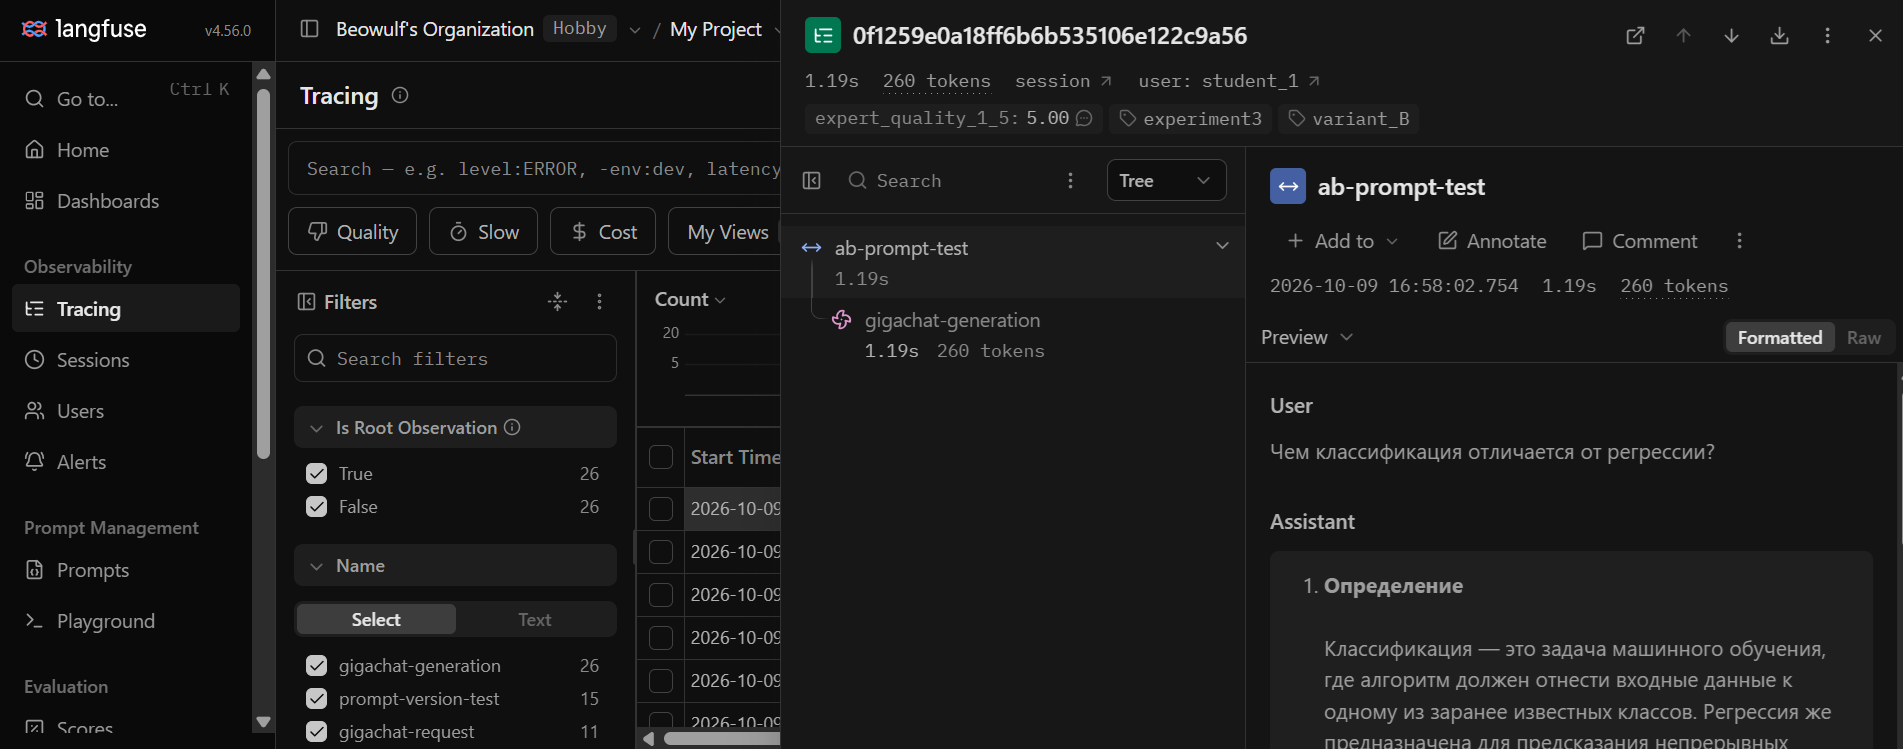

### Вывод

В ходе A/B-тестирования выполнено 30 запросов к `GigaChat-2`: по 15 для каждого варианта промпта. В Langfuse записаны версии промптов, теги A/B, длительность генерации, количество токенов и экспертные оценки качества по шкале 1–5.

**Вариант A (v2)** показал более высокую скорость (1,38 с против 1,63 с) и меньший расход токенов (246,53 против 310,80). **Вариант B (v3)** получил немного более высокую среднюю оценку качества (4,47 против 4,27) и меньший разброс оценок.

При этом статистический тест Манна — Уитни не выявил значимого различия в оценках качества (*p* = 0,6818). Следовательно, нельзя утверждать, что один из промптов статистически превосходит другой по качеству.

В рамках данного эксперимента **вариант A предпочтительнее по скорости и экономичности**, тогда как вариант B потенциально интереснее с точки зрения качества и стабильности структуры ответов. Для уверенного выбора по качеству потребуется более масштабный и сбалансированный эксперимент.

A/B-тестирование оказалось полезным инструментом: оно позволило количественно сравнить промпты и показать, что усложнение инструкций не обязательно приводит к статистически подтверждённому улучшению качества.

## Задание 4. Влияние параметров генерации

Исследуется влияние `temperature`, `max_tokens` и системной инструкции на ответы модели `GigaChat-2`.

Для одинакового вопроса сравниваются длительность генерации, длина ответа, расход токенов и вариативность содержания. Параметры каждого запуска сохраняются в Langfuse metadata.

Цель — определить наиболее стабильную, наиболее креативную и наиболее быструю конфигурацию.

In [33]:
experiment_question = (
    "Объясни, что такое переобучение модели машинного обучения. "
    "Приведи пример из повседневной жизни."
)

system_prompts = {
    "neutral": (
        "Ты преподаватель машинного обучения. "
        "Отвечай точно, понятно и по существу."
    ),
    "creative": (
        "Ты креативный преподаватель. "
        "Объясняй технические понятия через яркие и необычные аналогии. "
        "Сохраняй фактическую точность."
    ),
}

baseline_params = {
    "temperature": 0.2,
    "top_p": 1.0,
    "max_tokens": 300,
    "system_prompt": "neutral",
}

In [34]:
experiment_configs = (
    [
        {"name": "baseline", **baseline_params}
        for _ in range(3)
    ]
    + [
        {"name": "temp_0.7", **baseline_params, "temperature": 0.7}
        for _ in range(3)
    ]
    + [
        {"name": "temp_1.0", **baseline_params, "temperature": 1.0}
        for _ in range(3)
    ]
    + [
        {"name": "max_tokens_100", **baseline_params, "max_tokens": 100},
        {"name": "max_tokens_500", **baseline_params, "max_tokens": 500},
        {"name": "creative_system", **baseline_params, "system_prompt": "creative"},
    ]
)

print("Количество запросов:", len(experiment_configs))

Количество запросов: 12


Функция генерации с трейсингом:

In [35]:
def call_parameter_experiment(config):
    messages = [
        {
            "role": "system",
            "content": system_prompts[config["system_prompt"]],
        },
        {
            "role": "user",
            "content": experiment_question,
        },
    ]

    params = {
        "temperature": config["temperature"],
        "top_p": config["top_p"],
        "max_tokens": config["max_tokens"],
    }

    metadata = {
        **params,
        "system_prompt": config["system_prompt"],
        "experiment": config["name"],
    }

    with langfuse.start_as_current_observation(
        as_type="span",
        name="parameter-experiment",
        input=messages,
        metadata=metadata,
    ) as trace:

        with propagate_attributes(
            user_id="student_1",
            session_id="practice_5_parameters",
            tags=["experiment4", config["name"]],
        ):

            with langfuse.start_as_current_observation(
                as_type="generation",
                name="gigachat-generation",
                model=MODEL,
                input=messages,
                model_parameters=params,
                metadata=metadata,
            ) as generation:

                start = time.perf_counter()

                response = gigachat_client.chat({
                    "model": MODEL,
                    "messages": messages,
                    **params,
                })

                elapsed = time.perf_counter() - start

                answer = response.choices[0].message.content
                usage = response.usage

                generation.update(
                    output=answer,
                    usage_details={
                        "input_tokens": usage.prompt_tokens,
                        "output_tokens": usage.completion_tokens,
                        "total_tokens": usage.total_tokens,
                    },
                    metadata={
                        **metadata,
                        "generation_time_sec": round(elapsed, 3),
                    },
                )

            trace.update(output=answer)

    return {
        "experiment": config["name"],
        **params,
        "system_prompt": config["system_prompt"],
        "time_sec": elapsed,
        "answer_chars": len(answer),
        "completion_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
        "answer": answer,
    }

In [36]:
parameter_results = []

for i, config in enumerate(experiment_configs, start=1):
    result = call_parameter_experiment(config)
    parameter_results.append(result)

    print(
        f"{i:02d}/{len(experiment_configs)} | "
        f"{result['experiment']:18} | "
        f"{result['time_sec']:.2f} sec | "
        f"{result['answer_chars']} chars | "
        f"{result['completion_tokens']} output tokens"
    )

langfuse.flush()

01/12 | baseline           | 2.98 sec | 1384 chars | 278 output tokens
02/12 | baseline           | 1.71 sec | 1275 chars | 256 output tokens
03/12 | baseline           | 1.70 sec | 1318 chars | 258 output tokens
04/12 | temp_0.7           | 1.92 sec | 1510 chars | 300 output tokens
05/12 | temp_0.7           | 1.34 sec | 993 chars | 201 output tokens
06/12 | temp_0.7           | 1.36 sec | 1025 chars | 201 output tokens
07/12 | temp_1.0           | 1.90 sec | 1627 chars | 300 output tokens
08/12 | temp_1.0           | 1.92 sec | 1497 chars | 300 output tokens
09/12 | temp_1.0           | 1.67 sec | 1310 chars | 263 output tokens
10/12 | max_tokens_100     | 0.99 sec | 493 chars | 100 output tokens
11/12 | max_tokens_500     | 1.49 sec | 1041 chars | 213 output tokens
12/12 | creative_system    | 1.28 sec | 915 chars | 187 output tokens


In [37]:
parameter_df = pd.DataFrame(parameter_results)

parameter_df[
    [
        "experiment",
        "temperature",
        "top_p",
        "max_tokens",
        "system_prompt",
        "time_sec",
        "answer_chars",
        "completion_tokens",
    ]
]

,experiment,temperature,top_p,max_tokens,system_prompt,time_sec,answer_chars,completion_tokens
0,baseline,0.2,1.0,300,neutral,2.981786,1384,278
1,baseline,0.2,1.0,300,neutral,1.711012,1275,256
2,baseline,0.2,1.0,300,neutral,1.695385,1318,258
3,temp_0.7,0.7,1.0,300,neutral,1.916011,1510,300
4,temp_0.7,0.7,1.0,300,neutral,1.339204,993,201
5,temp_0.7,0.7,1.0,300,neutral,1.363854,1025,201
6,temp_1.0,1.0,1.0,300,neutral,1.902176,1627,300
7,temp_1.0,1.0,1.0,300,neutral,1.918637,1497,300
8,temp_1.0,1.0,1.0,300,neutral,1.670562,1310,263
9,max_tokens_100,0.2,1.0,100,neutral,0.994607,493,100


In [38]:
parameter_summary = (
    parameter_df
    .groupby("experiment")
    .agg(
        requests=("experiment", "count"),
        avg_time_sec=("time_sec", "mean"),
        min_time_sec=("time_sec", "min"),
        max_time_sec=("time_sec", "max"),
        std_time_sec=("time_sec", "std"),
        avg_answer_chars=("answer_chars", "mean"),
        std_answer_chars=("answer_chars", "std"),
        avg_completion_tokens=("completion_tokens", "mean"),
    )
    .round(2)
)

parameter_summary

,requests,avg_time_sec,min_time_sec,max_time_sec,std_time_sec,avg_answer_chars,std_answer_chars,avg_completion_tokens
experiment,,,,,,,,
baseline,3,2.13,1.70,2.98,0.74,1325.67,54.90,264.00
creative_system,1,1.28,1.28,1.28,NaN,915.00,NaN,187.00
max_tokens_100,1,0.99,0.99,0.99,NaN,493.00,NaN,100.00
max_tokens_500,1,1.49,1.49,1.49,NaN,1041.00,NaN,213.00
temp_0.7,3,1.54,1.34,1.92,0.33,1176.00,289.69,234.00
temp_1.0,3,1.83,1.67,1.92,0.14,1478.00,159.35,287.67


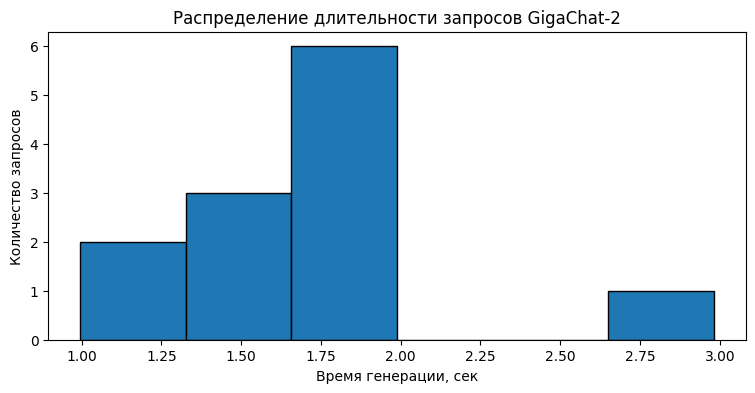

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(parameter_df["time_sec"], bins=6, edgecolor="black")
plt.xlabel("Время генерации, сек")
plt.ylabel("Количество запросов")
plt.title("Распределение длительности запросов GigaChat-2")
plt.show()

In [40]:
for i, row in parameter_df.iterrows():
    print("\n" + "=" * 80)
    print(f"RUN {i + 1}: {row['experiment']}")
    print(row["answer"])


RUN 1: baseline
Переобучение (overfitting) в машинном обучении — это ситуация, когда модель чрезмерно адаптируется к обучающим данным, настолько сильно, что начинает "запоминать" детали этих данных вместо того, чтобы выявлять общие закономерности и эффективно обобщать информацию. Такая модель хорошо работает на уже знакомой ей обучающей выборке, но плохо справляется с новыми, ранее не виденными данными (тестовой выборкой).

Простым примером из повседневной жизни является следующая ситуация:

Представь, что ты учишь своего ребенка различать домашних животных. Ты показываешь ему фотографии собак, кошек, кроликов и других зверей и объясняешь особенности каждого животного. Ребенок внимательно смотрит на каждую картинку и запоминает мельчайшие детали каждой особи: цвет шерсти, форму морды, длину лапок и т.д. Однако, когда ты потом спрашиваешь его про животное, которого он раньше не видел, ребенок начинает путаться и ошибаться, потому что он запомнил слишком много деталей именно тех фотогра

Пример из Langfuse:

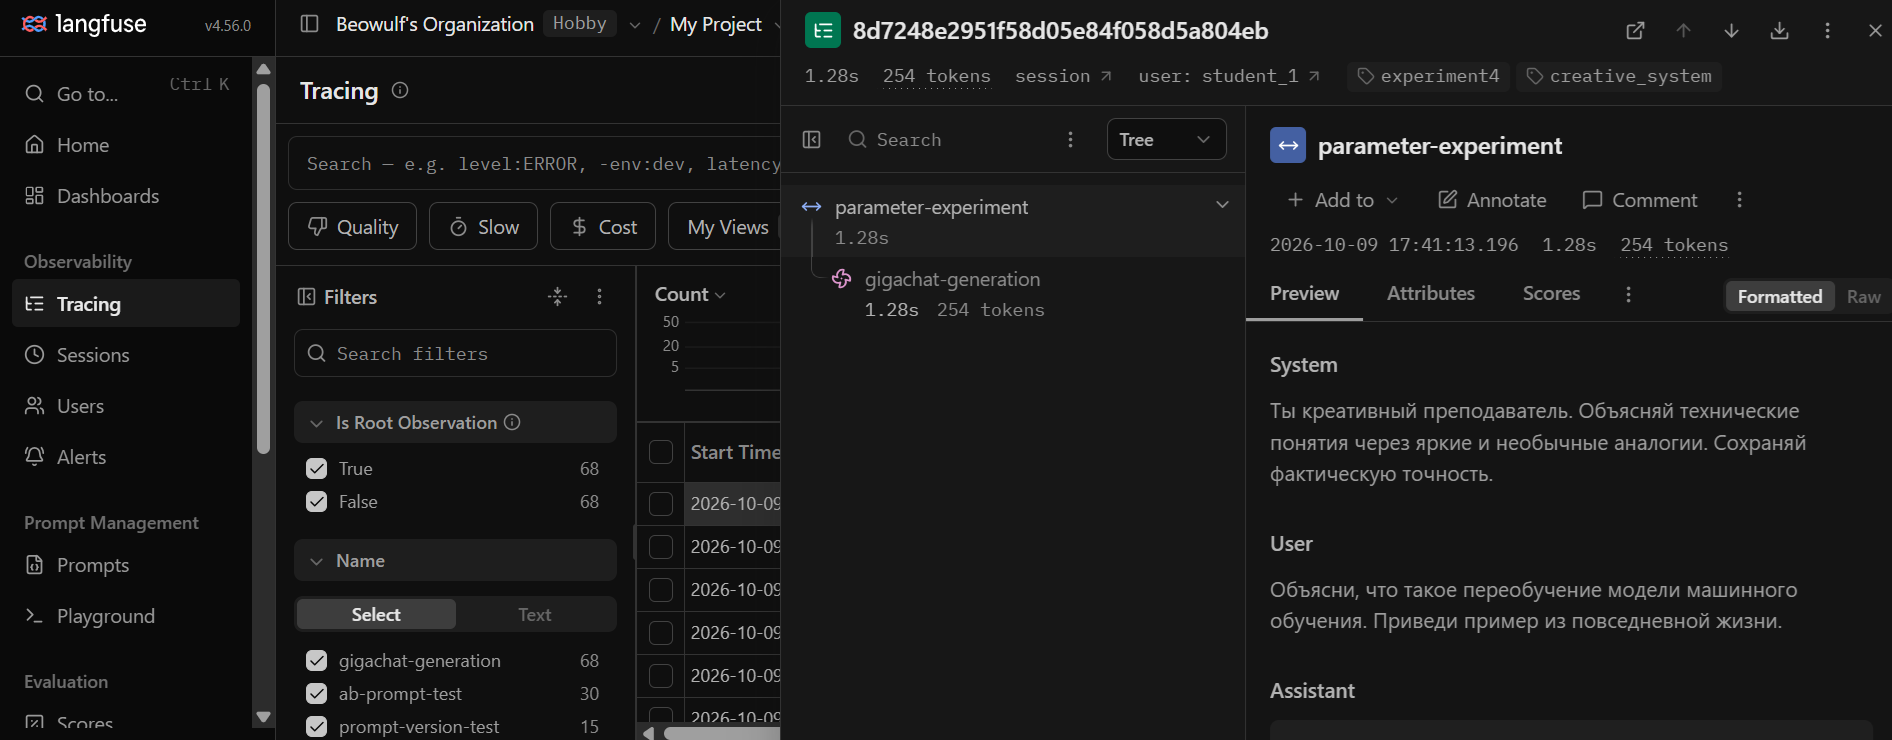

### Вывод

В ходе эксперимента выполнено 12 запросов к `GigaChat-2` с различными параметрами генерации. Все параметры и результаты записаны в Langfuse.

**Температура** заметно влияет на вариативность содержания. При `temperature=0.2` ответы были наиболее последовательными и использовали похожие примеры. При повышении температуры до 0.7 и 1.0 увеличилось разнообразие формулировок и аналогий, но некоторые объяснения стали менее точными.

**Ограничение `max_tokens`** влияет на максимальную длину ответа и может сокращать время генерации. Конфигурация `max_tokens=100` оказалась самой быстрой (0,99 с), однако ответ был обрезан. Увеличение лимита до 500 не привело к обязательному увеличению длины ответа.

**Системная инструкция** также существенно влияет на стиль генерации. Креативный system prompt позволил получить необычную аналогию даже при низкой температуре.

Большинство запросов выполнялось за 1–2 секунды. При этом единичные колебания задержки не позволяют сделать уверенный вывод о зависимости скорости от температуры.

Таким образом, для получения **стабильных и точных ответов** предпочтительна низкая температура, а для **более разнообразных и креативных ответов** можно повышать температуру или изменять системную инструкцию. Значение `max_tokens` следует выбирать достаточным для завершённого ответа.

Для данного сценария разумным базовым вариантом является `temperature=0.2`, `top_p=1.0`, `max_tokens=300`, с возможностью дополнительного ограничения длины ответа через инструкции.

## Задание 5. Evaluation pipeline для ML-ассистента

Реализуется система, объясняющая основные понятия машинного обучения в JSON-формате.

Для проверки качества создаётся dataset из шести вопросов с эталонными ответами. Оценка проводится по двум метрикам:

- `format_valid` — корректность формата JSON и наличие обязательных полей;
- `factuality` — фактическая правильность ответа относительно эталона, оцениваемая LLM-as-a-Judge.

Дополнительно рассчитывается среднее качество по всему эксперименту и анализируется один неудачный trace.

In [41]:
DATASET_NAME = "practice-5-ml-qa"

evaluation_data = [
    {
        "question": "Что такое переобучение модели?",
        "expected": (
            "Переобучение — ситуация, когда модель хорошо работает "
            "на обучающих данных, но плохо обобщает на новых данных."
        ),
    },
    {
        "question": "Чем классификация отличается от регрессии?",
        "expected": (
            "Классификация предсказывает категорию или класс, "
            "а регрессия предсказывает числовое значение."
        ),
    },
    {
        "question": "Что такое эмбеддинги?",
        "expected": (
            "Эмбеддинги — числовые векторные представления объектов, "
            "позволяющие отражать их смысловые или другие отношения."
        ),
    },
    {
        "question": "Для чего используется Cross-Encoder?",
        "expected": (
            "Cross-Encoder совместно обрабатывает пару текстов "
            "и оценивает степень их соответствия или релевантности."
        ),
    },
    {
        "question": "Что такое RAG?",
        "expected": (
            "RAG означает Retrieval-Augmented Generation — подход, "
            "при котором языковая модель использует информацию, "
            "извлечённую из внешних источников."
        ),
    },
    {
        "question": "Зачем нужна валидационная выборка?",
        "expected": (
            "Валидационная выборка используется для выбора модели, "
            "настройки гиперпараметров и контроля качества "
            "без использования тестовой выборки."
        ),
    },
]

Создадим dataset в облачном Langfuse:

In [42]:
langfuse.create_dataset(
    name=DATASET_NAME,
    description="Оценка качества ответов ML-ассистента",
)

for item in evaluation_data:
    langfuse.create_dataset_item(
        dataset_name=DATASET_NAME,
        input={"question": item["question"]},
        expected_output={"definition": item["expected"]},
    )

print("Dataset created:", DATASET_NAME)
print("Items:", len(evaluation_data))

Dataset created: practice-5-ml-qa
Items: 6


Проверка датасета:

In [43]:
dataset = langfuse.get_dataset(DATASET_NAME)

print("Dataset:", dataset.name)
print("Items:", len(dataset.items))

for item in dataset.items:
    print("\nQuestion:", item.input["question"])
    print("Expected:", item.expected_output["definition"])

Dataset: practice-5-ml-qa
Items: 6

Question: Зачем нужна валидационная выборка?
Expected: Валидационная выборка используется для выбора модели, настройки гиперпараметров и контроля качества без использования тестовой выборки.

Question: Что такое RAG?
Expected: RAG означает Retrieval-Augmented Generation — подход, при котором языковая модель использует информацию, извлечённую из внешних источников.

Question: Для чего используется Cross-Encoder?
Expected: Cross-Encoder совместно обрабатывает пару текстов и оценивает степень их соответствия или релевантности.

Question: Что такое эмбеддинги?
Expected: Эмбеддинги — числовые векторные представления объектов, позволяющие отражать их смысловые или другие отношения.

Question: Чем классификация отличается от регрессии?
Expected: Классификация предсказывает категорию или класс, а регрессия предсказывает числовое значение.

Question: Что такое переобучение модели?
Expected: Переобучение — ситуация, когда модель хорошо работает на обучающих да

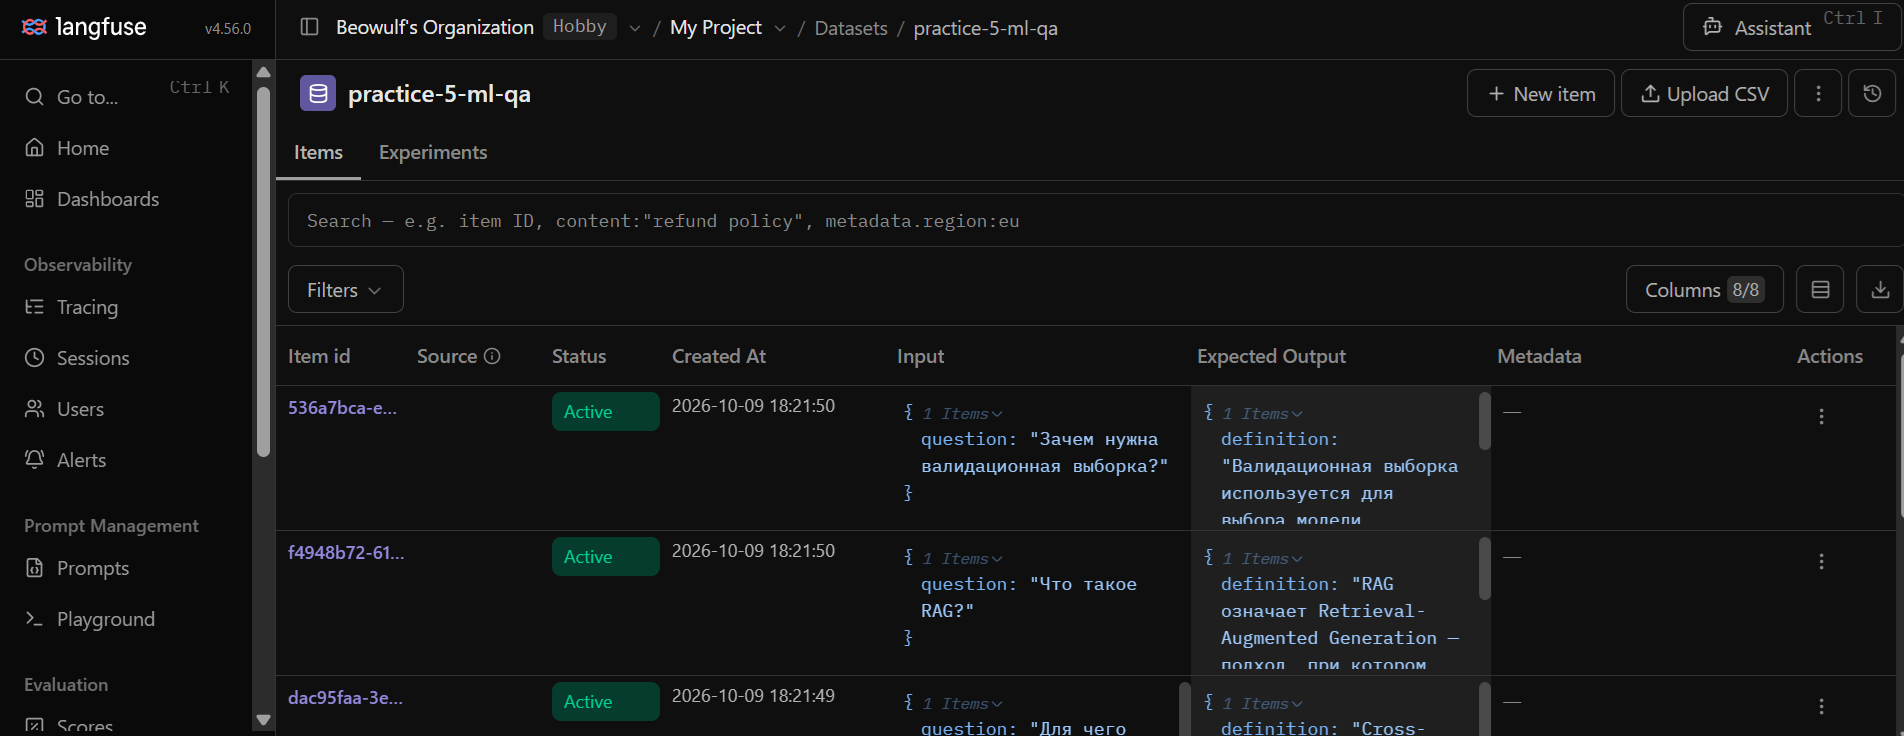

Пишем prompt и task для генерации. Сначала зададим инструкцию. Модель должна вернуть JSON с двумя полями: definition и example.

In [44]:
import json
import re
from langfuse import Evaluation

evaluation_system_prompt = """
Ты помощник для изучения машинного обучения.

Ответь на вопрос кратко и фактически правильно.
Верни только JSON-объект с двумя полями:
- "definition": определение понятия;
- "example": короткий практический пример.

Не добавляй Markdown или текст вне JSON.
"""

Теперь функция, которую будет вызывать Langfuse Experiment Runner для каждого элемента dataset:

In [45]:
def evaluation_task(*, item, **kwargs):
    question = item.input["question"]

    response = gigachat_client.chat({
        "model": MODEL,
        "messages": [
            {"role": "system", "content": evaluation_system_prompt},
            {"role": "user", "content": question},
        ],
        "temperature": 0.2,
        "max_tokens": 300,
    })

    return response.choices[0].message.content

Метрика для проверки формата:

In [46]:
def format_evaluator(*, output, **kwargs):
    try:
        data = json.loads(output)

        valid = (
            isinstance(data, dict)
            and all(
                isinstance(data.get(key), str) and data[key].strip()
                for key in ["definition", "example"]
            )
        )

    except (json.JSONDecodeError, TypeError):
        valid = False

    return Evaluation(
        name="format_valid",
        value=1.0 if valid else 0.0,
        comment="JSON format and required fields validation",
    )

Метрика принимает значения:
- 1 — формат корректен;
- 0 — JSON некорректен или обязательное поле отсутствует.

Вторая метрика будет сравнивать определение модели с эталонным ответом.
Для экономии токенов используем ту же GigaChat-2. Судья должен возвращать оценку от 1 до 5. Чтобы уменьшить риск проблем с парсингом, попросим вернуть только одно число.

In [47]:
def factuality_evaluator(*, output, expected_output, **kwargs):
    reference = expected_output["definition"]

    judge_prompt = f"""
Оцени фактическую правильность ответа по шкале от 1 до 5.

Эталон:
{reference}

Ответ модели:
{output}

Критерии:
1 — неверный ответ;
2 — существенные фактические ошибки;
3 — частично правильный ответ;
4 — в целом правильный, с небольшими неточностями;
5 — фактически правильный ответ.

Оцени прежде всего определение понятия.
Верни только одно число от 1 до 5.
"""

    response = gigachat_client.chat({
        "model": MODEL,
        "messages": [
            {"role": "user", "content": judge_prompt}
        ],
        "temperature": 0,
        "max_tokens": 20,
    })

    raw_score = response.choices[0].message.content.strip()
    match = re.search(r"\b[1-5]\b", raw_score)

    if not match:
        raise ValueError(f"Некорректная оценка судьи: {raw_score}")

    score = int(match.group())

    return Evaluation(
        name="factuality",
        value=float(score),
        comment="LLM-as-a-Judge: factual correctness (1-5)",
    )

### Агрегированная оценка качества

Дополнительно рассчитывается `avg_factuality` — средняя оценка фактической правильности по всем примерам dataset.

Это позволяет оценить качество всего эксперимента, а не только отдельных ответов.

In [48]:
def average_factuality(*, item_results, **kwargs):
    scores = [
        evaluation.value
        for result in item_results
        for evaluation in result.evaluations
        if evaluation.name == "factuality"
        and evaluation.value is not None
    ]

    if not scores:
        return Evaluation(
            name="avg_factuality",
            value=None,
        )

    return Evaluation(
        name="avg_factuality",
        value=sum(scores) / len(scores),
        comment="Average factuality score across dataset (1-5)",
    )

Запускаем эксперимент:

In [49]:
dataset = langfuse.get_dataset(DATASET_NAME)

experiment_result = dataset.run_experiment(
    name="ML Assistant Evaluation",
    run_name="ml-assistant-v1",
    description="JSON format validation and factuality evaluation",
    task=evaluation_task,
    evaluators=[
        format_evaluator,
        factuality_evaluator,
    ],
    run_evaluators=[
        average_factuality,
    ],
    max_concurrency=1,
)

langfuse.flush()

print(experiment_result.format())

Individual Results: Hidden (6 items)
💡 Set include_item_results=True to view them

──────────────────────────────────────────────────
🧪 Experiment: ML Assistant Evaluation
📋 Run name: ml-assistant-v1 - JSON format validation and factuality evaluation
6 items
Evaluations:
  • factuality
  • format_valid

Average Scores:
  • factuality: 4.667
  • format_valid: 0.500

Run Evaluations:
  • avg_factuality: 4.667
    💭 Average factuality score across dataset (1-5)

🔗 Dataset Run:
   https://cloud.langfuse.com/project/cmv0ouvyn09uzad0jeuqte1vl/datasets/cmv145mag00fwad0kqnv1jxp1/runs/8d19a74f-9a37-4a0f-848a-a32c23cb1d27


In [50]:
print(
    experiment_result.format(
        include_item_results=True
    )
)


1. Item 1:
   Input:    {'question': 'Зачем нужна валидационная выборка?'}
   Expected: {'definition': 'Валидационная выборка используется для выбора модели, настройки гиперпараметров и контроля качества без использования тестовой выборки.'}
   Actual:   {
"definition": "Валидационная выборка используетс...
   Scores:
     • format_valid: 1.000
       💭 JSON format and required fields validation
     • factuality: 4.000
       💭 LLM-as-a-Judge: factual correctness (1-5)

   Trace ID: 0a368ce7dc570131f8e1daa7cbceabde

2. Item 2:
   Input:    {'question': 'Что такое RAG?'}
   Expected: {'definition': 'RAG означает Retrieval-Augmented Generation — подход, при котором языковая модель использует информацию, извлечённую из внешних источников.'}
   Actual:   {
"definition": "RAG" означает Retrieval-Augmented...
   Scores:
     • format_valid: 0.000
       💭 JSON format and required fields validation
     • factuality: 4.000
       💭 LLM-as-a-Judge: factual correctness (1-5)

   Trace ID: 2d5

In [51]:
print("Experiment URL:", experiment_result.dataset_run_url)

Experiment URL: https://cloud.langfuse.com/project/cmv0ouvyn09uzad0jeuqte1vl/datasets/cmv145mag00fwad0kqnv1jxp1/runs/8d19a74f-9a37-4a0f-848a-a32c23cb1d27


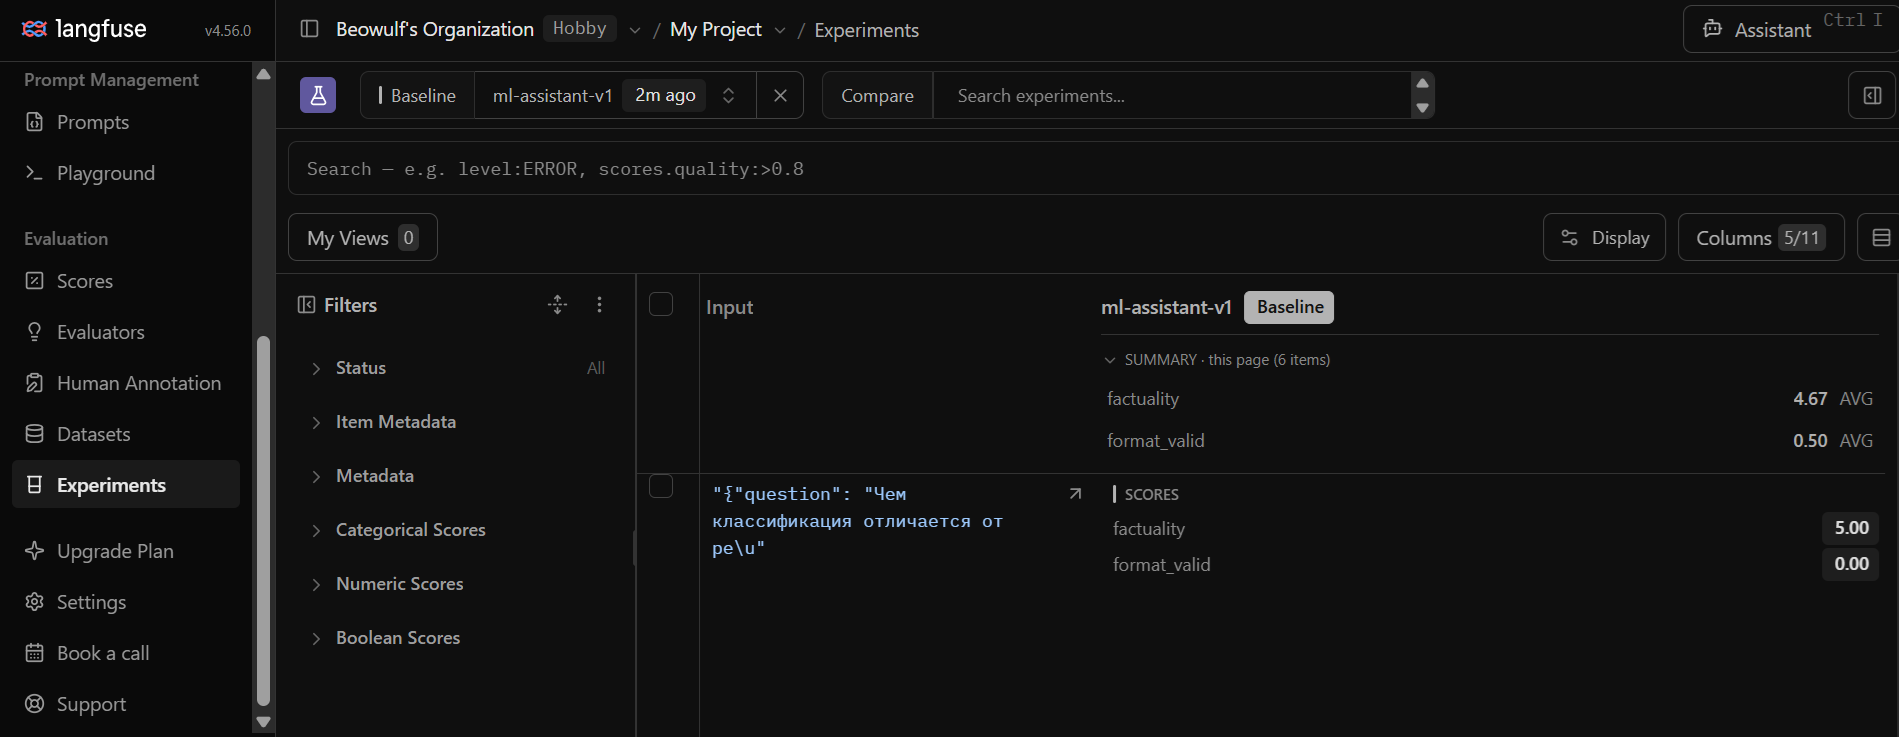

Готовим данные для анализа ошибок:

In [52]:
rows = []

for result in experiment_result.item_results:
    scores = {
        evaluation.name: evaluation.value
        for evaluation in result.evaluations
    }

    rows.append({
        "question": result.item.input["question"],
        "answer": result.output,
        "format_valid": scores.get("format_valid"),
        "factuality": scores.get("factuality"),
    })

evaluation_df = pd.DataFrame(rows)

evaluation_df[
    ["question", "format_valid", "factuality"]
]

,question,format_valid,factuality
0,Зачем нужна валидационная выборка?,1.0,4.0
1,Что такое RAG?,0.0,4.0
2,Для чего используется Cross-Encoder?,0.0,5.0
3,Что такое эмбеддинги?,1.0,5.0
4,Чем классификация отличается от регрессии?,0.0,5.0
5,Что такое переобучение модели?,1.0,5.0


Посмотрим ответы, отсортировав их по качеству:

In [53]:
for _, row in evaluation_df.sort_values("factuality").iterrows():
    print("\n" + "=" * 80)
    print("QUESTION:", row["question"])
    print("FORMAT VALID:", row["format_valid"])
    print("FACTUALITY:", row["factuality"])
    print("ANSWER:", row["answer"])


QUESTION: Зачем нужна валидационная выборка?
FORMAT VALID: 1.0
FACTUALITY: 4.0
ANSWER: {
"definition": "Валидационная выборка используется для оценки производительности модели на данных, которые она еще не видела, чтобы предотвратить переобучение и выбрать оптимальную гиперпараметрическую конфигурацию.",
"example": "Для выбора наилучшего количества слоев в сверточной сети использовалась валидационная выборка, содержащая 10% данных."
}

QUESTION: Что такое RAG?
FORMAT VALID: 0.0
FACTUALITY: 4.0
ANSWER: {
"definition": "RAG" означает Retrieval-Augmented Generation и относится к подходам генеративного искусственного интеллекта, где модели используют внешнюю информацию из базы знаний или документов для улучшения качества своих ответов.",
"example": "RAG-модель может извлекать релевантную информацию из базы знаний и включать её в ответы на запросы пользователей."
}

QUESTION: Для чего используется Cross-Encoder?
FORMAT VALID: 0.0
FACTUALITY: 5.0
ANSWER: ```json
{
  "definition": "Cross-Enc

### Вывод

В рамках задания реализован evaluation pipeline для учебного ML-ассистента с использованием Langfuse и `GigaChat-2`. Создан dataset из шести вопросов с эталонными определениями, настроена генерация ответов и две собственные метрики:

- **`format_valid`** — детерминированная проверка корректности JSON и обязательных строковых полей `definition` и `example`.
- **`factuality`** — оценка фактической правильности ответа относительно эталона с помощью LLM-as-a-Judge по шкале 1–5.

Средняя оценка `factuality` составила **4,67/5**, тогда как `format_valid` — только **0,50** (3 из 6 ответов соответствуют формату).

Анализ неудачного trace для вопроса о RAG показал, что модель дала содержательно правильное определение, но сформировала синтаксически некорректный JSON. В других ответах встречались Markdown-обёртки и нарушение типов обязательных полей.

Таким образом, основная проблема системы — не столько фактическая правильность, сколько **нестабильное соблюдение структурированного формата**.

В следующем эксперименте стоило бы использовать JSON Schema или структурированный вывод, а также уточнить требования к полям и проверить, насколько это повышает `format_valid`. Дополнительно полезно расширить dataset и использовать независимую модель для оценки фактической правильности.

Эксперимент показал, что сочетание code-based и LLM-as-a-Judge метрик позволяет выявлять разные классы ошибок, которые невозможно обнаружить одной метрикой.